In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

In [2]:
file_path = "Dry_Bean_Dataset.xlsx"
df = pd.read_excel(file_path)
df.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [3]:
df.shape

(13611, 17)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  object 
dtypes: float64(1

In [5]:
enc = LabelEncoder()
df['Class'] = enc.fit_transform(df['Class'])
df.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,5
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,5
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,5
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,5
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,5


In [6]:
enc.classes_

array(['BARBUNYA', 'BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SEKER', 'SIRA'],
      dtype=object)

In [7]:
X = df.drop(['Class'], axis=1)
y = df['Class']
X = StandardScaler().fit_transform(X)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X,y,random_state=42)

In [9]:
X_train = torch.tensor(X_train, dtype = torch.float32)
y_train = torch.tensor(y_train.values, dtype = torch.long)

X_test = torch.tensor(X_test, dtype = torch.float32)
y_test = torch.tensor(y_test.values, dtype = torch.long)

In [10]:
tr_ds = TensorDataset(X_train, y_train)
te_ds = TensorDataset(X_test, y_test)

bs = 64

tr_l = DataLoader(tr_ds, batch_size=bs, shuffle=True)
te_l = DataLoader(te_ds, batch_size=bs, shuffle=False)

In [11]:
class DryBeanClassificationMLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.ll1 = nn.Linear(16,64)
        self.ll2 = nn.Linear(64,32)
        self.ll3 = nn.Linear(32,16)

        self.bn1 = nn.BatchNorm1d(64)
        self.bn2 = nn.BatchNorm1d(32)
        self.bn3 = nn.BatchNorm1d(16)

        self.op = nn.Linear(16,7)

    def forward(self,x):
        x = self.ll1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.ll2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.ll3(x)
        x = self.bn3(x)
        x = F.relu(x)
        x = self.op(x)
        return x

model = DryBeanClassificationMLP()
print(model)

DryBeanClassificationMLP(
  (ll1): Linear(in_features=16, out_features=64, bias=True)
  (ll2): Linear(in_features=64, out_features=32, bias=True)
  (ll3): Linear(in_features=32, out_features=16, bias=True)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn3): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (op): Linear(in_features=16, out_features=7, bias=True)
)


In [12]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)

In [ ]:
epochs = 20

tr_ls = []
te_ls = []

for epoch in range(epochs):

    #training
    model.train()
    tr_b = []
    for X_batch, y_batch in tr_l:
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        tr_b.append(loss.item())
    tr_ls.append(np.mean(tr_b))

    #testing
    model.eval()
    te_b = []
    with torch.no_grad():
        for X_batch, y_batch in te_l:
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            te_b.append(loss.item())
    te_ls.append(np.mean(te_b))

    if(epoch+1)%4==0:
        print(f"Epoch: {epoch+1:2d}/{epochs} | Train loss: {tr_ls[-1]:.4f} | Test loss: {te_ls[-1]:.4f}")

Epoch:  4/20 | Train loss: 0.2690 | Test loss: 0.2130
Epoch:  8/20 | Train loss: 0.2322 | Test loss: 0.1969
Epoch: 12/20 | Train loss: 0.2171 | Test loss: 0.1913
Epoch: 16/20 | Train loss: 0.2160 | Test loss: 0.1969
Epoch: 20/20 | Train loss: 0.2087 | Test loss: 0.1892


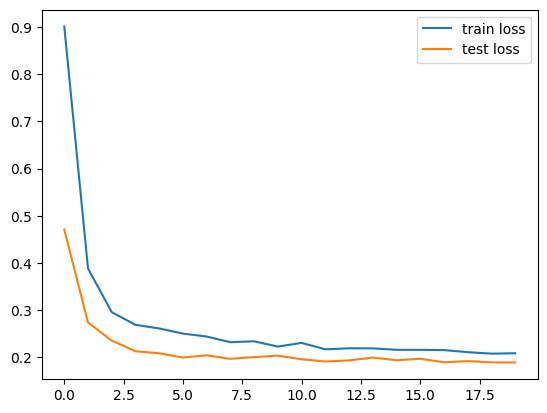

In [15]:
plt.plot(tr_ls, label="train loss")
plt.plot(te_ls, label="test loss")
plt.legend()

In [16]:
model.eval()
with torch.no_grad():
    pred = model(X_test)
    classes = torch.argmax(pred, dim=1)

print(confusion_matrix(y_test, classes))
print(classification_report(y_test, classes, target_names=enc.classes_))

[[311   0  20   0   2   3   8]
 [  0 142   0   0   0   0   0]
 [  8   0 386   0   4   2   2]
 [  0   0   0 776   1   8  66]
 [  1   0   9   4 467   0   5]
 [  3   0   0   9   0 486  15]
 [  0   0   1  45   7   3 609]]
              precision    recall  f1-score   support

    BARBUNYA       0.96      0.90      0.93       344
      BOMBAY       1.00      1.00      1.00       142
        CALI       0.93      0.96      0.94       402
    DERMASON       0.93      0.91      0.92       851
       HOROZ       0.97      0.96      0.97       486
       SEKER       0.97      0.95      0.96       513
        SIRA       0.86      0.92      0.89       665

    accuracy                           0.93      3403
   macro avg       0.95      0.94      0.94      3403
weighted avg       0.93      0.93      0.93      3403

